# Small Model: Logistic Regression

This notebook presents the Small Model in our experiment: multiclass Logistic Regression. We compare colour, HOG, LBP and spatial features under normal images, blur and brightness changes. The main aim is to compare both normal classification performance and robustness as the image quality changes.

## Data and experiment setup

The experiment treats the four feature representations as four different descriptions of the same image dataset. Every representation follows the same training and testing plan, so differences in the final scores mainly reflect the information captured by the features.

In [1]:
import csv
from concurrent.futures import ThreadPoolExecutor
import gc
import os
import pickle
from pathlib import Path

import numpy as np
from sklearn.linear_model import LogisticRegression

FEATURE_DIR = Path('features')
RESULT_DIR = Path('results')
MODEL_RESULT_DIR = RESULT_DIR / 'logistic_regression'
MODEL_RESULT_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_KEYS = ['colour', 'hog', 'lbp', 'spatial']
CONDITION_ORDER = [
    'clean',
    'blur_mild', 'blur_medium', 'blur_severe',
    'brightness_mild', 'brightness_medium', 'brightness_severe',
]
CONDITION_FILES = {
    'clean': 'clean.npz',
    'blur_mild': 'blur_mild.npz',
    'blur_medium': 'blur_medium.npz',
    'blur_severe': 'blur_severe.npz',
    'brightness_mild': 'brightness_mild.npz',
    'brightness_medium': 'brightness_medium.npz',
    'brightness_severe': 'brightness_severe.npz',
}
CONDITION_META = {
    'clean': {'corruption': 'clean', 'severity_name': 'clean', 'severity_level': 0, 'severity_value': 0.0},
    'blur_mild': {'corruption': 'blur', 'severity_name': 'mild', 'severity_level': 1, 'severity_value': 1.0},
    'blur_medium': {'corruption': 'blur', 'severity_name': 'medium', 'severity_level': 2, 'severity_value': 2.0},
    'blur_severe': {'corruption': 'blur', 'severity_name': 'severe', 'severity_level': 3, 'severity_value': 3.0},
    'brightness_mild': {'corruption': 'brightness', 'severity_name': 'mild', 'severity_level': 1, 'severity_value': 0.8},
    'brightness_medium': {'corruption': 'brightness', 'severity_name': 'medium', 'severity_level': 2, 'severity_value': 0.6},
    'brightness_severe': {'corruption': 'brightness', 'severity_name': 'severe', 'severity_level': 3, 'severity_value': 0.4},
}

OUTER_K = 10
INNER_K = 3
RANDOM_SEED = 42
C_GRID = [0.001, 0.01, 0.1]
SOLVER = 'sag'
TOL = 1e-3
MAX_ITER = 1000
INNER_WORKERS = min(len(C_GRID), os.cpu_count() or 1)

## Check condition alignment

The clean, blur and brightness versions must describe the same images in the same order. This alignment lets us compare the prediction for one original image across different image conditions.

In [2]:
# Get the path of one condition file.
def condition_path(condition_name):
    path = FEATURE_DIR / CONDITION_FILES[condition_name]
    return path


# Read only the indices and labels for alignment checking.
def read_indices_and_labels(condition_name):
    with np.load(condition_path(condition_name), allow_pickle=False) as data:
        indices = np.asarray(data['indices'])
        labels = np.asarray(data['labels'])
    return indices, labels


# Check that every condition matches the clean labels and indices.
def validate_condition_metadata():
    reference_indices, reference_labels = read_indices_and_labels('clean')
    assert len(reference_indices) == len(reference_labels)
    for condition_name in CONDITION_ORDER[1:]:
        indices, labels = read_indices_and_labels(condition_name)
        assert np.array_equal(indices, reference_indices)
        assert np.array_equal(labels, reference_labels)
    return reference_indices, reference_labels


REFERENCE_INDICES, Y = validate_condition_metadata()
N_CLASSES = int(np.max(Y)) + 1

## Use fixed outer and inner folds

The experiment uses one shared 10-part outer split and one shared 3-part inner split. Logistic Regression creates this common split when needed, and the other models reuse it. This gives every model the same training and testing samples for a fair comparison.

In [3]:
# Use the saved folds, or create them once if the file is missing.
FOLD_FILE = RESULT_DIR / 'outer_and_inner_folds.pkl'

if FOLD_FILE.exists():
    with FOLD_FILE.open('rb') as f:
        fold_data = pickle.load(f)
    OUTER_FOLDS = fold_data['outer_folds']
    INNER_FOLDS_BY_OUTER = fold_data['inner_folds_by_outer']
else:
    # Make balanced folds separately for each class.
    def make_stratified_folds(labels, n_folds, seed):
        rng = np.random.default_rng(seed)
        fold_indices = [[] for _ in range(n_folds)]
        for class_label in np.unique(labels):
            class_indices = np.flatnonzero(labels == class_label)
            rng.shuffle(class_indices)
            for position, sample_index in enumerate(class_indices):
                fold_indices[position % n_folds].append(int(sample_index))
        return [np.array(sorted(indices), dtype=np.int64) for indices in fold_indices]

    all_indices = np.arange(len(Y), dtype=np.int64)
    outer_test_folds = make_stratified_folds(Y, OUTER_K, RANDOM_SEED)
    OUTER_FOLDS = []
    INNER_FOLDS_BY_OUTER = {}
    for fold_id, outer_test_indices in enumerate(outer_test_folds):
        outer_train_indices = np.setdiff1d(all_indices, outer_test_indices, assume_unique=True)
        inner_position_folds = make_stratified_folds(
            Y[outer_train_indices], INNER_K, RANDOM_SEED + fold_id + 1
        )
        OUTER_FOLDS.append({
            'fold_id': fold_id,
            'train_indices': outer_train_indices,
            'test_indices': outer_test_indices,
        })
        INNER_FOLDS_BY_OUTER[fold_id] = [
            outer_train_indices[positions] for positions in inner_position_folds
        ]
    with FOLD_FILE.open('wb') as f:
        pickle.dump({
            'outer_folds': OUTER_FOLDS,
            'inner_folds_by_outer': INNER_FOLDS_BY_OUTER,
            'outer_k': OUTER_K,
            'inner_k': INNER_K,
            'random_seed': RANDOM_SEED,
        }, f)

## Standardization, model and metrics

The standardization follows the same rule as the model training: the training data defines the centre and scale, and the other parts use those values. This keeps the evaluation separate from the training information. The confusion matrix then gives Accuracy, Macro-Precision, Macro-Recall and Macro-F1.

In [4]:
# Calculate standardization values from the training data.
def fit_standardizer(X_train):
    mean = np.mean(X_train, axis=0, dtype=np.float64)
    std = np.std(X_train, axis=0, dtype=np.float64)
    std[std < 1e-12] = 1.0
    return mean.astype(np.float32), std.astype(np.float32)


# Apply the saved standardization values to another split.
def apply_standardizer(X, mean, std):
    return ((X - mean) / std).astype(np.float32, copy=False)


# Calculate the required classification scores manually.
def classification_metrics(y_true, y_pred, n_classes):
    y_true = np.asarray(y_true, dtype=np.int64)
    y_pred = np.asarray(y_pred, dtype=np.int64)
    confusion = np.zeros((n_classes, n_classes), dtype=np.int64)
    for true_label, predicted_label in zip(y_true, y_pred):
        confusion[true_label, predicted_label] += 1

    total = confusion.sum()
    accuracy = float(np.trace(confusion) / total) if total else 0.0
    precision_values = []
    recall_values = []
    f1_values = []
    for class_id in range(n_classes):
        true_positive = confusion[class_id, class_id]
        false_positive = confusion[:, class_id].sum() - true_positive
        false_negative = confusion[class_id, :].sum() - true_positive
        precision_denominator = true_positive + false_positive
        recall_denominator = true_positive + false_negative
        precision = true_positive / precision_denominator if precision_denominator else 0.0
        recall = true_positive / recall_denominator if recall_denominator else 0.0
        f1_denominator = precision + recall
        f1 = 2.0 * precision * recall / f1_denominator if f1_denominator else 0.0
        precision_values.append(precision)
        recall_values.append(recall)
        f1_values.append(f1)

    return {
        'accuracy': accuracy,
        'macro_precision': float(np.mean(precision_values)),
        'macro_recall': float(np.mean(recall_values)),
        'macro_f1': float(np.mean(f1_values)),
        'confusion_matrix': confusion,
    }


# Train one multiclass Logistic Regression model.
def fit_logistic_model(X_train, y_train, C_value):
    model = LogisticRegression(
        C=float(C_value),
        solver=SOLVER,
        multi_class='multinomial',
        tol=TOL,
        max_iter=MAX_ITER,
        random_state=RANDOM_SEED,
    )
    model.fit(X_train, y_train)
    return model


# Get the number of iterations used by the solver.
def model_iterations(model):
    return int(np.max(np.asarray(model.n_iter_, dtype=np.int64)))

## Inner 3-fold hyperparameter tuning

The inner stage chooses the regularization strength for Logistic Regression. It compares three `C` values on clean training data and uses their mean Macro-F1 to select the strongest candidate. Parallel fitting reduces the time needed for these independent comparisons.

In [5]:
# Fit one C value on an inner training and validation split.
def fit_inner_candidate(X_inner_train, y_inner_train, X_inner_validation, y_inner_validation, C_value):
    model = fit_logistic_model(X_inner_train, y_inner_train, C_value)
    predictions = model.predict(X_inner_validation)
    metrics = classification_metrics(y_inner_validation, predictions, N_CLASSES)
    return C_value, metrics, model_iterations(model)


# Select the best C using the three inner folds.
def tune_logistic_C(X_clean, y, outer_train_indices, inner_global_folds, fold_id, feature_key):
    tuning_rows = []
    mean_score_by_C = {}

    for C_value in C_GRID:
        mean_score_by_C[float(C_value)] = []

    for inner_fold_id, inner_validation_indices in enumerate(inner_global_folds):
        inner_training_indices = np.setdiff1d(
            outer_train_indices, inner_validation_indices, assume_unique=True
        )
        inner_mean, inner_std = fit_standardizer(X_clean[inner_training_indices])
        X_inner_train = apply_standardizer(X_clean[inner_training_indices], inner_mean, inner_std)
        X_inner_validation = apply_standardizer(X_clean[inner_validation_indices], inner_mean, inner_std)

        with ThreadPoolExecutor(max_workers=INNER_WORKERS) as executor:
            candidate_results = list(executor.map(
                lambda C_value: fit_inner_candidate(
                    X_inner_train, y[inner_training_indices],
                    X_inner_validation, y[inner_validation_indices], C_value
                ),
                C_GRID,
            ))

        for C_value, metrics, n_iter in candidate_results:
            mean_score_by_C[float(C_value)].append(metrics['macro_f1'])
            tuning_rows.append({
                'feature_representation': feature_key,
                'outer_fold': fold_id,
                'C': C_value,
                'inner_fold': inner_fold_id,
                'inner_macro_f1': metrics['macro_f1'],
                'inner_n_iter': n_iter,
            })

        del X_inner_train, X_inner_validation
        gc.collect()

    mean_score_by_C = {
        C_value: float(np.mean(scores))
        for C_value, scores in mean_score_by_C.items()
    }

    best_C = min(
        mean_score_by_C,
        key=lambda value: (-mean_score_by_C[value], value),
    )
    return best_C, mean_score_by_C, tuning_rows

## Outer training and robustness evaluation

The outer stage estimates the final performance of the selected model. Each training part produces one model, and that model is tested across the clean, blur and brightness conditions. The change in score across these conditions describes the model's robustness.

In [6]:
# Load one feature matrix and keep it in float32.
def load_feature_matrix(condition_name, feature_key):
    with np.load(condition_path(condition_name), allow_pickle=False) as data:
        indices = np.asarray(data['indices'])
        labels = np.asarray(data['labels'])
        return np.asarray(data[feature_key], dtype=np.float32)


# Put one evaluation result into the output format.
def make_result_row(feature_key, fold_id, condition_name, best_C, n_train, n_test, metrics):
    metadata = CONDITION_META[condition_name]
    return {
        'model': 'multiclass_logistic_regression',
        'feature_representation': feature_key,
        'outer_fold': fold_id,
        'condition': condition_name,
        'corruption': metadata['corruption'],
        'severity_name': metadata['severity_name'],
        'severity_level': metadata['severity_level'],
        'severity_value': metadata['severity_value'],
        'C': best_C,
        'solver': SOLVER,
        'tol': TOL,
        'max_iter': MAX_ITER,
        'n_iter': metrics['n_iter'],
        'n_train': n_train,
        'n_test': n_test,
        'accuracy': metrics['accuracy'],
        'macro_precision': metrics['macro_precision'],
        'macro_recall': metrics['macro_recall'],
        'macro_f1': metrics['macro_f1'],
    }


# Run nested CV and robustness testing for one feature representation.
def evaluate_feature_representation(feature_key):
    print(f'Loading clean feature: {feature_key}')
    X_clean = load_feature_matrix('clean', feature_key)
    result_rows = []
    tuning_rows = []
    trained_states = []

    for outer_fold in OUTER_FOLDS:
        fold_id = outer_fold['fold_id']
        train_indices = outer_fold['train_indices']
        test_indices = outer_fold['test_indices']
        outer_mean, outer_std = fit_standardizer(X_clean[train_indices])
        X_outer_train = apply_standardizer(X_clean[train_indices], outer_mean, outer_std)
        best_C, tuning_scores, fold_tuning_rows = tune_logistic_C(
            X_clean, Y, train_indices, INNER_FOLDS_BY_OUTER[fold_id], fold_id, feature_key
        )
        tuning_rows.extend(fold_tuning_rows)
        model = fit_logistic_model(X_outer_train, Y[train_indices], best_C)
        clean_predictions = model.predict(apply_standardizer(X_clean[test_indices], outer_mean, outer_std))
        clean_metrics = classification_metrics(Y[test_indices], clean_predictions, N_CLASSES)
        clean_metrics['n_iter'] = model_iterations(model)
        result_rows.append(make_result_row(
            feature_key, fold_id, 'clean', best_C, len(train_indices), len(test_indices), clean_metrics
        ))
        trained_states.append({
            'fold_id': fold_id,
            'train_indices': train_indices,
            'test_indices': test_indices,
            'outer_mean': outer_mean,
            'outer_std': outer_std,
            'best_C': best_C,
            'model': model,
            'n_iter': model_iterations(model),
            'inner_scores': tuning_scores,
        })
        print(f'Feature={feature_key}, outer fold={fold_id}, best C={best_C}')

    for condition_name in CONDITION_ORDER[1:]:
        print(f'Evaluating condition: {condition_name}')
        X_condition = load_feature_matrix(condition_name, feature_key)
        for state in trained_states:
            test_indices = state['test_indices']
            X_test = apply_standardizer(
                X_condition[test_indices], state['outer_mean'], state['outer_std']
            )
            predictions = state['model'].predict(X_test)
            metrics = classification_metrics(Y[test_indices], predictions, N_CLASSES)
            metrics['n_iter'] = state['n_iter']
            result_rows.append(make_result_row(
                feature_key, state['fold_id'], condition_name, state['best_C'],
                len(state['train_indices']), len(test_indices), metrics
            ))
        del X_condition
        gc.collect()

    del X_clean, trained_states
    gc.collect()
    return result_rows, tuning_rows

## Run the Logistic Regression experiment

This section runs the complete experiment for all four feature representations. Each representation goes through parameter selection, final training and robustness testing. The SAG solver handles the Logistic Regression optimization, and the final tables support the comparison in the report.

In [7]:
all_result_rows = []
all_tuning_rows = []
for feature_key in FEATURE_KEYS:
    feature_rows, tuning_rows = evaluate_feature_representation(feature_key)
    all_result_rows.extend(feature_rows)
    all_tuning_rows.extend(tuning_rows)
    print(f'Completed feature representation: {feature_key}')

print(f'Total evaluation rows: {len(all_result_rows)}')
print(f'Total tuning rows: {len(all_tuning_rows)}')

Loading clean feature: colour
Feature=colour, outer fold=0, best C=0.1
Feature=colour, outer fold=1, best C=0.1
Feature=colour, outer fold=2, best C=0.1
Feature=colour, outer fold=3, best C=0.1
Feature=colour, outer fold=4, best C=0.1
Feature=colour, outer fold=5, best C=0.1
Feature=colour, outer fold=6, best C=0.1
Feature=colour, outer fold=7, best C=0.1
Feature=colour, outer fold=8, best C=0.1
Feature=colour, outer fold=9, best C=0.1
Evaluating condition: blur_mild
Evaluating condition: blur_medium
Evaluating condition: blur_severe
Evaluating condition: brightness_mild
Evaluating condition: brightness_medium
Evaluating condition: brightness_severe
Completed feature representation: colour
Loading clean feature: hog
Feature=hog, outer fold=0, best C=0.01
Feature=hog, outer fold=1, best C=0.01
Feature=hog, outer fold=2, best C=0.01
Feature=hog, outer fold=3, best C=0.01
Feature=hog, outer fold=4, best C=0.01
Feature=hog, outer fold=5, best C=0.01
Feature=hog, outer fold=6, best C=0.01
F

## Save the results

The result files keep the main information from the experiment in a form that we can analyse later. They connect each score with its feature representation, model setting, image condition and corruption severity.

In [8]:
# Save a list of result rows as a CSV file.
RESULT_COLUMNS = [
    'model', 'feature_representation', 'outer_fold', 'condition', 'corruption',
    'severity_name', 'severity_level', 'severity_value', 'C', 'solver', 'tol', 'max_iter', 'n_iter',
    'n_train', 'n_test',
    'accuracy', 'macro_precision', 'macro_recall', 'macro_f1',
]
TUNING_COLUMNS = [
    'feature_representation', 'outer_fold', 'C', 'inner_fold', 'inner_macro_f1', 'inner_n_iter',
]


def write_csv(path, rows, fieldnames):
    with path.open('w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


RESULT_CSV = MODEL_RESULT_DIR / 'logistic_regression_results.csv'
TUNING_CSV = MODEL_RESULT_DIR / 'logistic_regression_inner_tuning.csv'
RESULT_PICKLE = MODEL_RESULT_DIR / 'logistic_regression_results.pkl'
write_csv(RESULT_CSV, all_result_rows, RESULT_COLUMNS)
write_csv(TUNING_CSV, all_tuning_rows, TUNING_COLUMNS)
with RESULT_PICKLE.open('wb') as f:
    pickle.dump(all_result_rows, f)
print(f'Saved evaluation results to: {RESULT_CSV}')
print(f'Saved inner tuning results to: {TUNING_CSV}')
print(f'Saved pickle results to: {RESULT_PICKLE}')

Saved evaluation results to: results/logistic_regression/logistic_regression_results.csv
Saved inner tuning results to: results/logistic_regression/logistic_regression_inner_tuning.csv
Saved pickle results to: results/logistic_regression/logistic_regression_results.pkl


## Result analysis: fold predictions

This section gives a closer look at the clean-image results. The table shows how many test images each representation classifies correctly in each part of the experiment, together with the main scores.

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

ANALYSIS_RESULT_DIR = Path('results/logistic_regression')
RESULT_CSV_FOR_ANALYSIS = ANALYSIS_RESULT_DIR / 'logistic_regression_results.csv'
TUNING_CSV_FOR_ANALYSIS = ANALYSIS_RESULT_DIR / 'logistic_regression_inner_tuning.csv'
results_df = pd.read_csv(RESULT_CSV_FOR_ANALYSIS)
tuning_df = pd.read_csv(TUNING_CSV_FOR_ANALYSIS)
FEATURE_ORDER_FOR_ANALYSIS = ['colour', 'hog', 'lbp', 'spatial']
CONDITION_ORDER_FOR_ANALYSIS = [
    'clean', 'blur_mild', 'blur_medium', 'blur_severe',
    'brightness_mild', 'brightness_medium', 'brightness_severe',
]

### Clean condition: predictions for each outer fold

This table makes the Accuracy values easier to understand. It shows the relationship between the number of correct predictions, the number of mistakes and the total test size.

In [10]:
results_df['correct_predictions'] = np.rint(
    results_df['accuracy'] * results_df['n_test']
).astype(int)
results_df['incorrect_predictions'] = (
    results_df['n_test'] - results_df['correct_predictions']
).astype(int)
clean_fold_table = results_df[results_df['condition'] == 'clean'][[
    'feature_representation', 'outer_fold', 'n_test',
    'correct_predictions', 'incorrect_predictions',
    'accuracy', 'macro_f1', 'C', 'n_iter',
]].sort_values(['feature_representation', 'outer_fold'])
display(clean_fold_table.round(4))

,feature_representation,outer_fold,n_test,correct_predictions,incorrect_predictions,accuracy,macro_f1,C,n_iter
0,colour,0,1706,834,872,0.4889,0.4725,0.10,23
1,colour,1,1706,878,828,0.5147,0.4891,0.10,22
2,colour,2,1706,854,852,0.5006,0.4777,0.10,22
3,colour,3,1704,861,843,0.5053,0.4868,0.10,24
4,colour,4,1703,815,888,0.4786,0.4562,0.10,22
5,colour,5,1701,812,889,0.4774,0.4613,0.10,22
6,colour,6,1701,861,840,0.5062,0.4883,0.10,21
7,colour,7,1701,847,854,0.4979,0.4810,0.10,22
8,colour,8,1700,838,862,0.4929,0.4750,0.10,22
9,colour,9,1700,859,841,0.5053,0.4852,0.10,20


### 10-fold summary

The summary combines the results from all ten test parts. The mean describes the overall score, while the standard deviation shows how stable the result stays across different samples.

In [11]:
summary_df = (
    results_df.groupby(['feature_representation', 'condition'], sort=False)
    .agg(
        n_test_mean=('n_test', 'mean'),
        correct_predictions_mean=('correct_predictions', 'mean'),
        accuracy_mean=('accuracy', 'mean'),
        accuracy_std=('accuracy', 'std'),
        macro_f1_mean=('macro_f1', 'mean'),
        macro_f1_std=('macro_f1', 'std'),
    )
    .reset_index()
)
summary_df['feature_representation'] = pd.Categorical(
    summary_df['feature_representation'], categories=FEATURE_ORDER_FOR_ANALYSIS, ordered=True
)
summary_df['condition'] = pd.Categorical(
    summary_df['condition'], categories=CONDITION_ORDER_FOR_ANALYSIS, ordered=True
)
summary_df = summary_df.sort_values(['feature_representation', 'condition'])
display(summary_df.round(4))

,feature_representation,condition,n_test_mean,correct_predictions_mean,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std
0,colour,clean,1702.8,845.9,0.4968,0.0123,0.4773,0.0113
1,colour,blur_mild,1702.8,821.0,0.4821,0.0081,0.4532,0.0086
2,colour,blur_medium,1702.8,805.9,0.4733,0.0093,0.4432,0.0090
3,colour,blur_severe,1702.8,798.7,0.4691,0.0110,0.4382,0.0108
4,colour,brightness_mild,1702.8,730.1,0.4288,0.0078,0.3885,0.0069
5,colour,brightness_medium,1702.8,457.1,0.2684,0.0035,0.2103,0.0050
6,colour,brightness_severe,1702.8,340.6,0.2000,0.0042,0.1139,0.0069
7,hog,clean,1702.8,1234.9,0.7252,0.0171,0.7286,0.0168
8,hog,blur_mild,1702.8,1131.7,0.6646,0.0166,0.6634,0.0160
9,hog,blur_medium,1702.8,985.7,0.5789,0.0151,0.5764,0.0156


### Inner CV hyperparameter selection

This part explains the regularization choice. The table shows which `C` values work best for the different representations and how their average inner Macro-F1 scores compare.

In [12]:
best_c_rows = []
for feature_key in FEATURE_ORDER_FOR_ANALYSIS:
    clean_rows = results_df[
        (results_df['feature_representation'] == feature_key)
        & (results_df['condition'] == 'clean')
    ]
    c_counts = clean_rows['C'].value_counts().sort_index()
    max_count = c_counts.max()
    best_values = c_counts[c_counts == max_count].index.tolist()
    best_c_rows.append({
        'feature_representation': feature_key,
        'most_common_C': ', '.join(str(value) for value in best_values),
        'most_common_count': int(max_count),
        'C_distribution': '; '.join(
            f'{value}: {int(count)} folds' for value, count in c_counts.items()
        ),
    })
best_c_df = pd.DataFrame(best_c_rows)
display(best_c_df)

tuning_summary_df = (
    tuning_df.groupby(['feature_representation', 'C'], sort=False)['inner_macro_f1']
    .mean()
    .reset_index(name='mean_inner_macro_f1')
)
display(tuning_summary_df.round(4))

,feature_representation,most_common_C,most_common_count,C_distribution
0,colour,0.1,10,0.1: 10 folds
1,hog,0.01,10,0.01: 10 folds
2,lbp,0.1,10,0.1: 10 folds
3,spatial,0.01,10,0.01: 10 folds


,feature_representation,C,mean_inner_macro_f1
0,colour,0.001,0.4345
1,colour,0.010,0.4667
2,colour,0.100,0.4745
3,hog,0.001,0.7182
4,hog,0.010,0.7232
5,hog,0.100,0.7123
6,lbp,0.001,0.5193
7,lbp,0.010,0.5679
8,lbp,0.100,0.5782
9,spatial,0.001,0.7723


### Plots in the notebook

The plots turn the tables into a visual comparison. They show clean-image performance and the way Macro-F1 changes as blur or brightness becomes stronger.

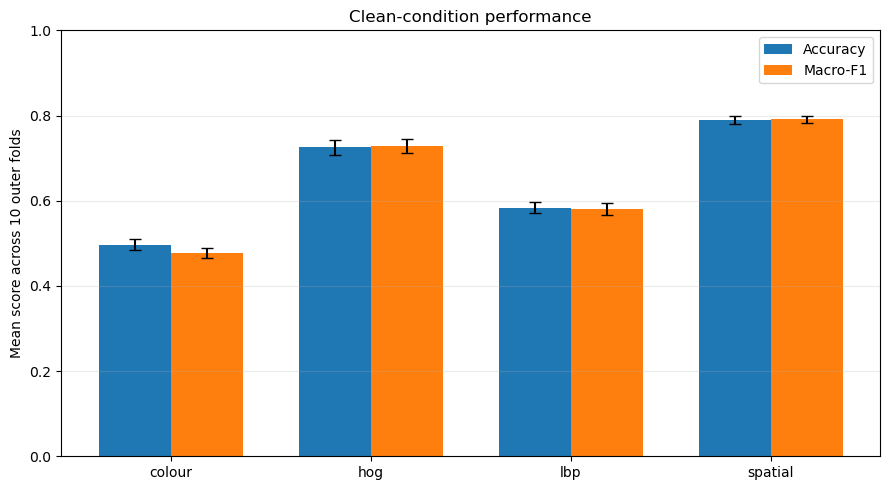

In [13]:
import matplotlib.pyplot as plt

clean_summary = summary_df[summary_df['condition'] == 'clean'].set_index(
    'feature_representation'
).loc[FEATURE_ORDER_FOR_ANALYSIS]
x = np.arange(len(FEATURE_ORDER_FOR_ANALYSIS))
width = 0.36
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width / 2, clean_summary['accuracy_mean'], width, yerr=clean_summary['accuracy_std'], capsize=4, label='Accuracy')
ax.bar(x + width / 2, clean_summary['macro_f1_mean'], width, yerr=clean_summary['macro_f1_std'], capsize=4, label='Macro-F1')
ax.set_xticks(x, FEATURE_ORDER_FOR_ANALYSIS)
ax.set_ylim(0, 1)
ax.set_ylabel('Mean score across 10 outer folds')
ax.set_title('Clean-condition performance')
ax.legend()
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
plt.show()
plt.close(fig)

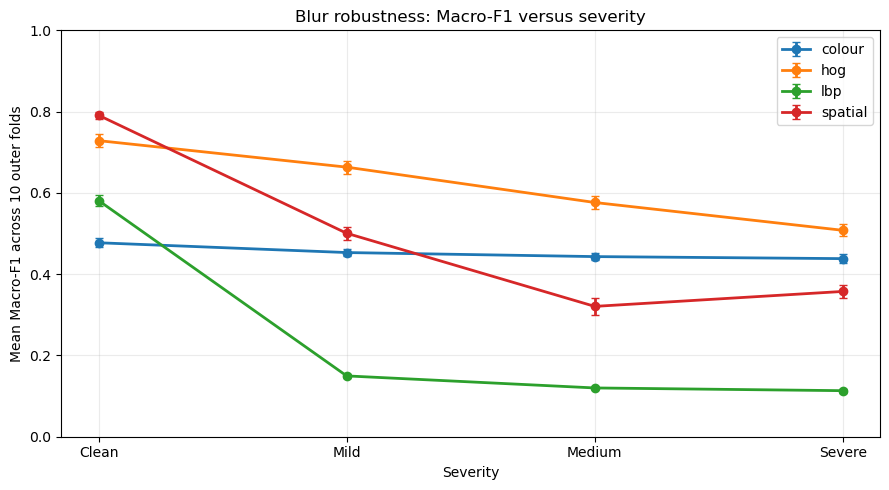

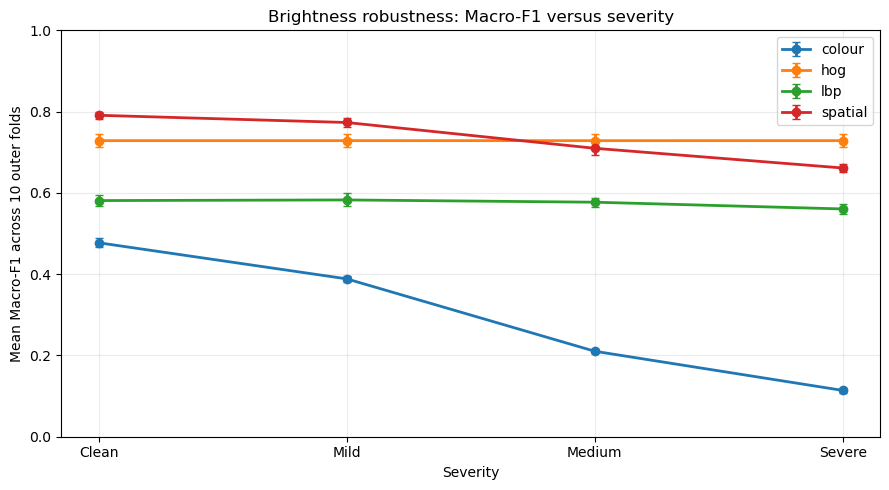

In [14]:
for corruption, condition_names, title in [
    ('blur', ['clean', 'blur_mild', 'blur_medium', 'blur_severe'], 'Blur robustness'),
    ('brightness', ['clean', 'brightness_mild', 'brightness_medium', 'brightness_severe'], 'Brightness robustness'),
]:
    fig, ax = plt.subplots(figsize=(9, 5))
    severity_labels = ['Clean', 'Mild', 'Medium', 'Severe']
    severity_levels = np.arange(len(severity_labels))
    for feature_key in FEATURE_ORDER_FOR_ANALYSIS:
        values = []
        errors = []
        for condition_name in condition_names:
            row = summary_df[
                (summary_df['feature_representation'] == feature_key)
                & (summary_df['condition'] == condition_name)
            ].iloc[0]
            values.append(row['macro_f1_mean'])
            errors.append(row['macro_f1_std'])
        ax.errorbar(severity_levels, values, yerr=errors, marker='o', capsize=3, linewidth=2, label=feature_key)
    ax.set_xticks(severity_levels, severity_labels)
    ax.set_ylim(0, 1)
    ax.set_xlabel('Severity')
    ax.set_ylabel('Mean Macro-F1 across 10 outer folds')
    ax.set_title(f'{title}: Macro-F1 versus severity')
    ax.legend()
    ax.grid(alpha=0.25)
    fig.tight_layout()
    plt.show()
    plt.close(fig)